# Функциональная компонента adversarial patch: от кандидатов до переноса между патчами

## 0. Общая постановка

Нас интересует не обучение патча и не внешнее сходство изображений, а
**внутренний механизм инференса**: какая часть изменения активаций Detect head
приводит к исчезновению одного заранее зафиксированного объекта класса
`person`.

Вычислительный путь:

$$
x\longrightarrow H(x)\longrightarrow
\text{pre-NMS candidates}\longrightarrow
\text{threshold+NMS}\longrightarrow\mathcal D_\theta(x).
$$

Для каждого чистого изображения $x$ выбирается самая уверенная post-NMS
детекция человека $t^\star$ и фиксируется её рамка $b^\star$. На изображение
накладывается патч:

$$
x^p=A(x,p,\ell).
$$

После этого отслеживается **тот же целевой объект**, а не новый глобальный
победитель:

$$
s_{\mathrm{track}}(x^p)=
\max_{\substack{j:c_j=\mathrm{person}\\
\operatorname{IoU}(b_j(x^p),b^\star)\ge0.5}}
s_j(x^p).
$$

Целевой объект считается скрытым при

$$
Y(x^p)=\mathbb 1[s_{\mathrm{track}}(x^p)<0.25]=1.
$$

> **Выдержка из `Method_Mathematical.md`, §1.**
> Механистическая интервенция выполняется на входах Detect head. После неё
> все последующие операции — Detect, decode, thresholding и NMS — остаются
> штатными. Чистая целевая детекция задаёт объект и эталонную рамку; после
> атаки объект отслеживается по IoU с этой рамкой.

### Обозначения, используемые далее

| Обозначение | Смысл |
|---|---|
| $x,\;x^p$ | чистое и атакованное изображения |
| $b^\star$ | фиксированная рамка целевого объекта |
| $H_l(x)$ | входная feature map Detect на FPN-уровне $l$ |
| $h_l^c,\;h_l^p$ | локальные clean/patched активации, развёрнутые в вектор |
| $\delta_l=h_l^p-h_l^c$ | реальная patch-delta активаций |
| $\mathcal R^\star$ | резерв pre-NMS кандидатов целевого объекта |
| $z_i,\;s_i$ | class-logit и confidence кандидата $i$ |
| $\iota_i$ | IoU рамки кандидата с $b^\star$ |
| $f_l(h_l)$ | вектор logits и IoU всех кандидатов резерва |
| $J_l$ | path-integrated Jacobian функции $f_l$ по $h_l$ |
| $U,\Sigma,V^\top$ | SVD-разложение якобиана |
| $\delta_l^J$ | проекция patch-delta на row space якобиана |
| repair | вычитание $\delta^J$ из patched-активаций |
| transplant | добавление $\delta^J$ к clean-активациям |

Все основные вмешательства выполняются в feature maps P3/P4/P5 **до Detect**.
В выбранном ниже примере все десять кандидатов находятся на P5 — выходе слоя
22, поступающем на вход Detect.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from IPython.display import display, Math

ROOT = Path(r"/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath")
DEMO = Path(r"/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/demo_artifacts/functional_component")
FULL = Path(r"/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/full_success_608d1fab828fcafd")
SHARED = Path(r"/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/shared_functional_space_outputs/shared_space_0e8b77cb38660969")
CROSS = Path(r"/Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/cross_patch_functional_space_outputs/cross_patch_7e8ac1c4d605125b")

meta = json.loads((DEMO / "metadata.json").read_text())
candidates = pd.read_csv(DEMO / "candidates.csv")
svd = np.load(DEMO / "svd_demo.npz")
full_rows = pd.read_csv(FULL / "joint_functional_rows.csv")
full_summary = pd.read_csv(FULL / "joint_functional_summary.csv")
shared_analytic = pd.read_csv(SHARED / "analytic_summary.csv")
shared_causal = pd.read_csv(SHARED / "causal_summary.csv")
cross_analytic = pd.read_csv(CROSS / "analytic_summary.csv")
cross_causal = pd.read_csv(CROSS / "causal_summary.csv")

sns.set_theme(style="whitegrid", context="notebook")
print({
    "example_id": meta["example_id"],
    "group": meta["analysis_group"],
    "level": meta["level_name"],
    "candidate_count": meta["n_candidates"],
})

{'example_id': '2241a17c14b865cd', 'group': 'hidden_low_conf_match', 'level': 'P5', 'candidate_count': 10}


## 1. Один объект представлен резервом кандидатов

Одна итоговая post-NMS детекция не означает, что внутри модели существует
только одно предсказание этого человека. Несколько соседних клеток Detect
порождают перекрывающиеся pre-NMS boxes; NMS оставляет победителя, но остальные
маршруты образуют резерв.

> **Выдержка из `Method_Mathematical.md`, §2–2.2.**
> Клетка $(l,y,u)$ — позиция во входной карте Detect; внутри неё находится
> вектор активаций. Кандидат — уже результат чтения этой позиции головой:
> logit, score и рамка. Один объект не тождествен одной клетке. Для появления
> объекта достаточно одного выжившего кандидата, а для скрытия необходимо
> подавить score или нарушить геометрию у всех кандидатов резерва.

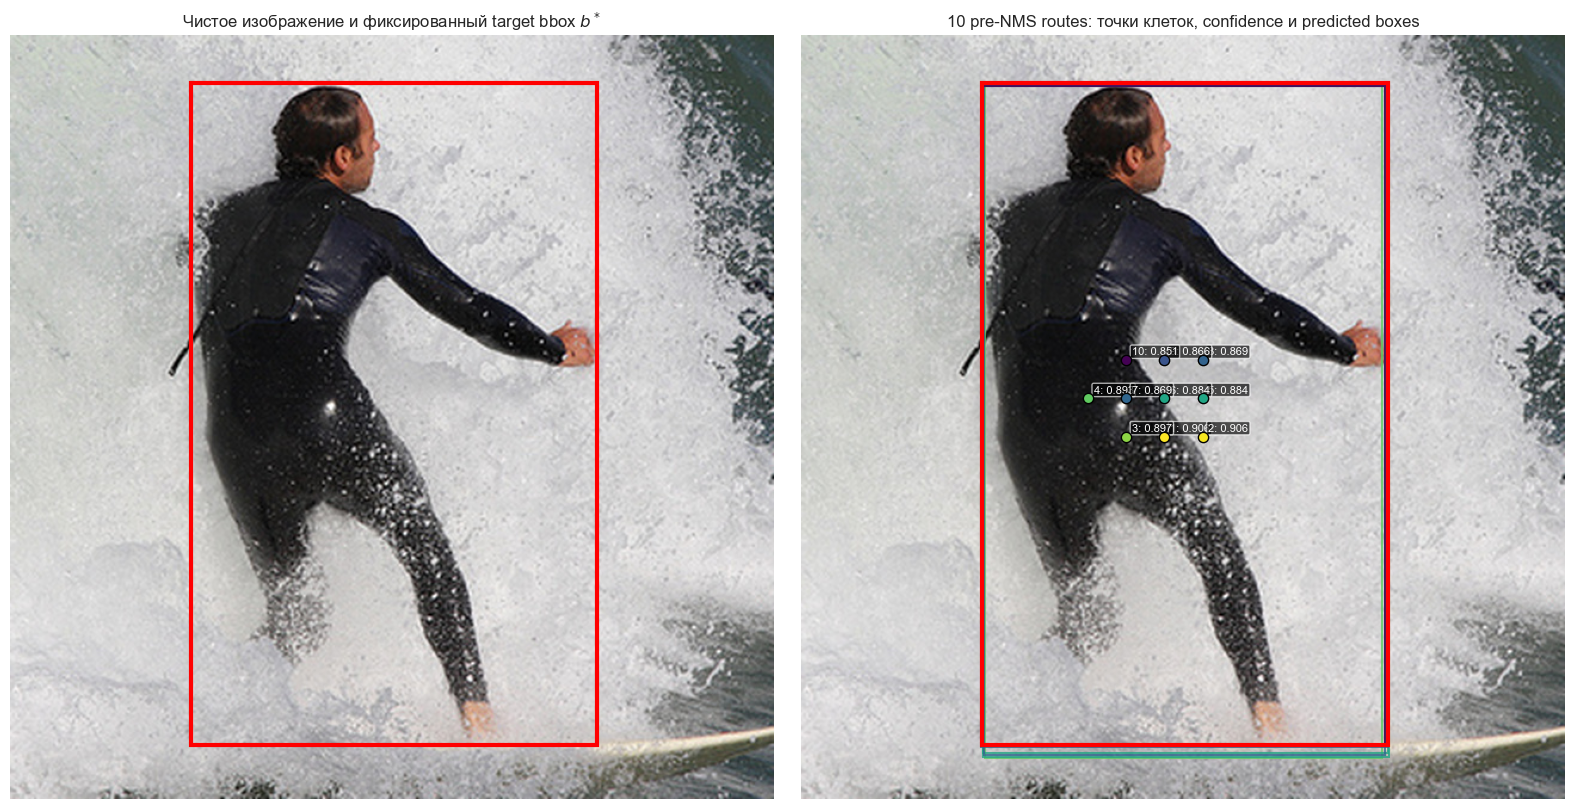

,level_index,y_index,x_index,clean_score,clean_iou,patched_score,patched_iou
0,2,10,9,0.9063,1.0000,0.0686,0.5150
1,2,10,10,0.9056,0.9941,0.0391,0.5014
2,2,10,8,0.8969,0.9900,0.0471,0.5639
3,2,9,7,0.8929,0.9581,0.0197,0.6419
4,2,9,10,0.8838,0.9772,0.0311,0.5005
5,2,9,9,0.8836,0.9839,0.0634,0.5228
6,2,9,8,0.8693,0.9719,0.0539,0.5781
7,2,8,10,0.8687,0.9889,0.0054,0.5147
8,2,8,9,0.8657,0.9926,0.0085,0.5771
9,2,8,8,0.8514,0.9855,0.0338,0.6459


In [2]:
clean = np.asarray(Image.open(DEMO / "clean.png").convert("RGB"))
target = meta["target_box"]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax in axes:
    ax.imshow(clean)
    ax.axis("off")

axes[0].add_patch(patches.Rectangle(
    (target[0], target[1]), target[2]-target[0], target[3]-target[1],
    fill=False, edgecolor="red", linewidth=3,
))
axes[0].set_title("Чистое изображение и фиксированный target bbox $b^*$")

cmap = plt.cm.viridis
norm = plt.Normalize(candidates.clean_score.min(), candidates.clean_score.max())
stride = 32  # P5 for 640×640 input
for rank, row in candidates.reset_index(drop=True).iterrows():
    color = cmap(norm(row.clean_score))
    axes[1].add_patch(patches.Rectangle(
        (row.clean_x1, row.clean_y1),
        row.clean_x2-row.clean_x1, row.clean_y2-row.clean_y1,
        fill=False, edgecolor=color, linewidth=1.5, alpha=0.8,
    ))
    route_x, route_y = (row.x_index + 0.5) * stride, (row.y_index + 0.5) * stride
    axes[1].scatter(route_x, route_y, s=55, color=color, edgecolor="black", zorder=5)
    axes[1].annotate(
        f"{rank+1}: {row.clean_score:.3f}",
        (route_x, route_y), xytext=(4, 4), textcoords="offset points",
        fontsize=8, color="white",
        bbox=dict(boxstyle="round,pad=.15", facecolor="black", alpha=.65),
    )
axes[1].add_patch(patches.Rectangle(
    (target[0], target[1]), target[2]-target[0], target[3]-target[1],
    fill=False, edgecolor="red", linewidth=3,
))
axes[1].set_title("10 pre-NMS routes: точки клеток, confidence и predicted boxes")
plt.tight_layout()
plt.show()

display(candidates[[
    "level_index", "y_index", "x_index",
    "clean_score", "clean_iou", "patched_score", "patched_iou"
]].round(4))

На clean-входе десять соседних P5-клеток дают почти одинаковые рамки
одного человека со score $0.85$–$0.91$. После патча score каждого маршрута
падает ниже $0.07$. Поэтому здесь скрытие — не исчезновение одного победителя,
а согласованное подавление всего резерва.

## 2. Что именно является выходом функции $f_l(h_l)$

Для $m_l$ кандидатов уровня $l$ определяем

$$
f_l(h_l)=
\begin{bmatrix}
z_1(h_l)\\
\vdots\\
z_{m_l}(h_l)\\
\iota_1(h_l)\\
\vdots\\
\iota_{m_l}(h_l)
\end{bmatrix}
\in\mathbb R^{2m_l},
\qquad
\iota_i(h_l)=
\operatorname{IoU}(\operatorname{decode}_i(h_l),b^\star).
$$

Первые $m_l$ строк — class-logits кандидатов, следующие $m_l$ — IoU их
decoded boxes с фиксированной рамкой. Вектор содержит именно те две причины,
по которым кандидат может перестать представлять объект: недостаточный score
или неправильную геометрию.

> **Выдержка из `Method_Mathematical.md`, §7.1–7.2.**
> Все каналы и позиции объединения локальных окон разворачиваются в
> $h_l\in\mathbb R^{d_l}$. При дифференцировании одного уровня остальные
> head branches фиксируются, поэтому якобиан измеряет чувствительность
> выбранных outputs к конкретной feature map. В формулах используется logit,
> поскольку он меньше насыщается около нуля и единицы, чем score.

In [3]:
m = meta["n_candidates"]
f_clean = svd["f_clean"]
f_patched = svd["f_patched"]
f_table = pd.DataFrame({
    "output": [f"z_{i+1}" for i in range(m)] + [f"IoU_{i+1}" for i in range(m)],
    "clean": f_clean,
    "patched": f_patched,
    "delta_output": f_patched - f_clean,
})
display(f_table.round(4))

def latex_vector(values):
    return r"\begin{bmatrix}" + r"\\".join(f"{v:.3f}" for v in values) + r"\end{bmatrix}"

display(Math(r"f_l(h_l^c)=" + latex_vector(f_clean)))
display(Math(r"f_l(h_l^p)=" + latex_vector(f_patched)))

,output,clean,patched,delta_output
0,z_1,2.2692,-2.6078,-4.8770
1,z_2,2.2616,-3.2023,-5.4640
2,z_3,2.1630,-3.0079,-5.1709
3,z_4,2.1211,-3.9055,-6.0266
4,z_5,2.0290,-3.4384,-5.4674
5,z_6,2.0273,-2.6934,-4.7207
6,z_7,1.8946,-2.8660,-4.7606
7,z_8,1.8899,-5.2137,-7.1036
8,z_9,1.8631,-4.7565,-6.6196
9,z_10,1.7454,-3.3526,-5.0981


<IPython.core.display.Math object>

<IPython.core.display.Math object>

В этом примере основное изменение — падение всех десяти logits. IoU
тоже изменяется, но большинство рамок остаётся геометрически сопоставимым с
объектом. Это конкретный `hidden_low_conf_match` случай.

## 3. Якобиан: какие изменения активаций читают эти outputs

Между clean и patched активациями проводится прямой путь

$$
\gamma_l(\alpha)=h_l^c+\alpha\delta_l,
\qquad
\delta_l=h_l^p-h_l^c.
$$

В каждой точке пути вычисляется

$$
J_l(\alpha)=
\frac{\partial f_l(\gamma_l(\alpha))}{\partial h_l}.
$$

Используется средний якобиан по трём midpoint-точкам:

$$
\widehat J_l=
\frac13\sum_{s=1}^{3}
J_l\left(\frac{s-\tfrac12}{3}\right).
$$

Строка $J$ соответствует одному logit или IoU, столбец — одной координате
локальных активаций. Поэтому $J\delta$ предсказывает совместное изменение
всего вектора $f_l$.

> **Выдержка из `Method_Mathematical.md`, §7.3.**
> Для точного интеграла вдоль пути выполняется
> $f(h^p)-f(h^c)=\bar J\delta$. В коде интеграл заменён тремя midpoint-точками,
> поэтому равенство становится численным приближением; его полнота проверяется
> сравнением $\widehat J\delta$ с разностью endpoints.

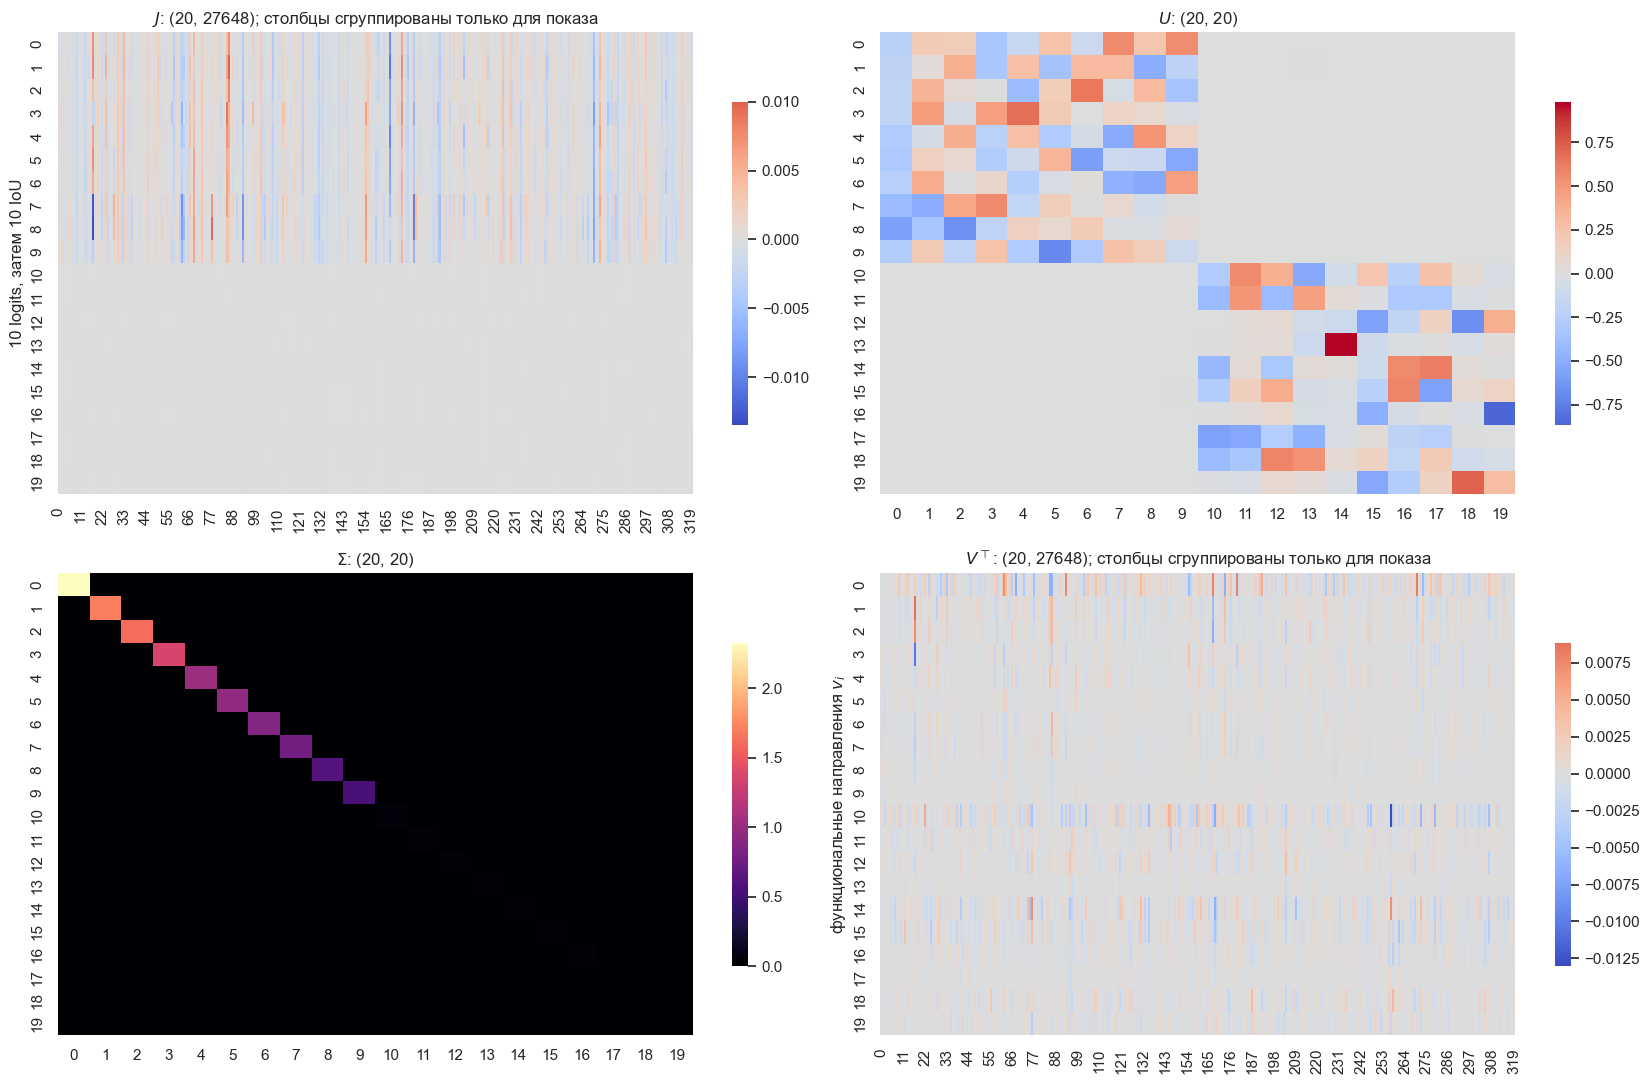

Первые элементы матриц без визуального сжатия:


,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000260
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,0,1,2,3,4,5,6,7
0,-0.237360,0.189450,0.188100,-0.330630,-0.150840,0.260070,-0.123560,0.550250
1,-0.213910,0.029790,0.379640,-0.335740,0.277310,-0.363570,0.310910,0.305940
2,-0.193170,0.358040,0.058350,0.005700,-0.407470,0.178950,0.640860,-0.049450
3,-0.200850,0.481380,-0.050140,0.463740,0.666600,0.212200,-0.002500,0.125170
4,-0.287100,-0.053950,0.386180,-0.224640,0.278110,-0.284350,-0.051660,-0.517380
5,-0.307120,0.156860,0.084500,-0.276330,-0.106730,0.348830,-0.590070,-0.119810
6,-0.246690,0.395900,0.001960,0.094640,-0.253820,-0.034220,0.017980,-0.475140
7,-0.411220,-0.505470,0.427000,0.564100,-0.180560,0.168200,0.002220,0.086520


,0,1,2,3,4,5,6,7
0,2.329390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,1.708880,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,1.616440,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,1.364600,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,1.024150,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.954890,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.875330,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.780990


,0,1,2,3,4,5,6,7
0,-0.000050,-0.000220,-0.000010,0.000230,0.000340,0.000290,0.000100,-0.000020
1,0.000060,-0.000380,-0.000570,-0.000190,0.000020,0.000290,0.000160,0.000070
2,-0.000060,-0.000410,0.000670,0.000550,0.000610,0.000260,-0.000150,-0.000010
3,0.000090,-0.000370,0.000330,0.000030,0.000050,-0.000020,-0.000230,0.000090
4,-0.000130,0.000450,0.000140,0.000210,0.000090,-0.000060,0.000100,0.000170
5,-0.000340,0.000770,0.001350,0.001040,0.000700,-0.000130,-0.000100,0.000060


{'J': (20, 27648), 'U': (20, 20), 'Sigma': (20, 20), 'Vt': (20, 27648), 'numerical_rank': 20, 'path_completeness_error': 0.0346}


In [4]:
J = svd["jacobian"]
U = svd["U"]
S = svd["singular"]
Vt = svd["Vt"]
Sigma = np.diag(S)

def block_mean(matrix, target_columns=320):
    if matrix.shape[1] <= target_columns:
        return matrix
    edges = np.linspace(0, matrix.shape[1], target_columns + 1, dtype=int)
    return np.stack([
        matrix[:, edges[i]:edges[i+1]].mean(axis=1)
        for i in range(target_columns)
    ], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(17, 11))
sns.heatmap(block_mean(J), center=0, cmap="coolwarm", ax=axes[0, 0], cbar_kws={"shrink": .7})
axes[0, 0].set_title(f"$J$: {J.shape}; столбцы сгруппированы только для показа")
axes[0, 0].set_ylabel("10 logits, затем 10 IoU")

sns.heatmap(U, center=0, cmap="coolwarm", ax=axes[0, 1], cbar_kws={"shrink": .7})
axes[0, 1].set_title(f"$U$: {U.shape}")

sns.heatmap(Sigma, cmap="magma", ax=axes[1, 0], cbar_kws={"shrink": .7})
axes[1, 0].set_title(f"$\\Sigma$: {Sigma.shape}")

sns.heatmap(block_mean(Vt), center=0, cmap="coolwarm", ax=axes[1, 1], cbar_kws={"shrink": .7})
axes[1, 1].set_title(f"$V^\\top$: {Vt.shape}; столбцы сгруппированы только для показа")
axes[1, 1].set_ylabel("функциональные направления $v_i$")
plt.tight_layout()
plt.show()

print("Первые элементы матриц без визуального сжатия:")
display(pd.DataFrame(J[:6, :8]).round(5).style.set_caption("J[:6, :8]"))
display(pd.DataFrame(U[:8, :8]).round(5).style.set_caption("U[:8, :8]"))
display(pd.DataFrame(Sigma[:8, :8]).round(5).style.set_caption("Σ[:8, :8]"))
display(pd.DataFrame(Vt[:6, :8]).round(5).style.set_caption("Vᵀ[:6, :8]"))

print({
    "J": J.shape,
    "U": U.shape,
    "Sigma": Sigma.shape,
    "Vt": Vt.shape,
    "numerical_rank": meta["numerical_rank"],
    "path_completeness_error": round(meta["linear_completeness_relative_error"], 4),
})

## 4. Что даёт SVD и как получается функциональная компонента

Разложение

$$
J=U\Sigma V^\top
$$

$$
J= \begin{pmatrix} | & | & | \\ u_1 & \cdots & u_m \\ | & | & | \end{pmatrix} \cdot \begin{pmatrix} \sigma_1 & 0 & \cdots \\ 0 & \sigma_2 & \cdots \\ \cdots & \cdots & \cdots \end{pmatrix} \cdot \begin{pmatrix} | & | & | \\ v_1 & \cdots & v_n \\ | & | & | \end{pmatrix}^T
$$

выбирает ортонормированные направления $v_i$ в пространстве активаций,
которые читаются выбранными outputs:

$$
Jv_i=\sigma_i u_i.
$$

Для каждого направления измеряется, сколько реальной patch-delta в него
попало:

$$
c_i=v_i^\top\delta.
$$

Направления с ненулевыми singular values образуют row space. Собираем
проекцию дельты обратно в исходных координатах:

$$
\delta^J
=\sum_{i:\sigma_i>0}c_i v_i
=V_rV_r^\top\delta.
$$

Остаток

$$
\delta^\perp=\delta-\delta^J
$$

ортогонален row space и в первом порядке не меняет выбранные outputs:

$$
J\delta^\perp\approx0.
$$

> **Выдержка из `Method_Mathematical.md`, §7.4–7.5.**
> SVD не ищет самые большие активации и не выбирает отдельные top-k нейроны.
> Оно сначала определяет совместные направления, которые локальная модель
> использует для чтения score/IoU, а затем оставляет проекцию реально
> возникшей patch-delta на эти направления. Компонента не генерируется из
> градиента: она является частью наблюдавшейся clean→patched дельты.

,quantity,value
0,||δ||² (локальное окно),1.119770e+04
1,||δᴶ||²,6.157958e+02
2,||δ⊥||²,1.058191e+04
3,доля δᴶ в локальной энергии,5.499304e-02
4,доля δᴶ во всей feature-delta,4.875456e-03
5,||Jδ⊥|| / ||Jδ||,1.501080e-07


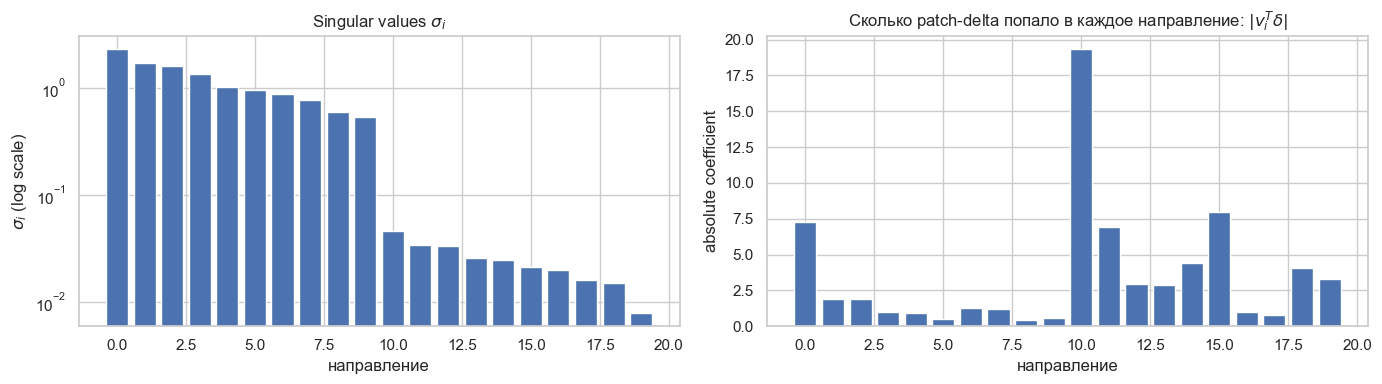

In [5]:
delta = svd["delta"]
functional = svd["functional"]
residual = svd["residual"]
coefficients = Vt @ delta

demo_numbers = pd.DataFrame({
    "quantity": [
        "||δ||² (локальное окно)",
        "||δᴶ||²",
        "||δ⊥||²",
        "доля δᴶ в локальной энергии",
        "доля δᴶ во всей feature-delta",
        "||Jδ⊥|| / ||Jδ||",
    ],
    "value": [
        np.dot(delta, delta),
        np.dot(functional, functional),
        np.dot(residual, residual),
        np.dot(functional, functional) / np.dot(delta, delta),
        meta["functional_fraction_of_full"],
        np.linalg.norm(J @ residual) / np.linalg.norm(J @ delta),
    ],
})
display(demo_numbers)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(np.arange(len(S)), S)
axes[0].set_yscale("log")
axes[0].set_title("Singular values $\\sigma_i$")
axes[0].set_xlabel("направление")
axes[0].set_ylabel("$\\sigma_i$ (log scale)")

axes[1].bar(np.arange(len(coefficients)), np.abs(coefficients))
axes[1].set_title("Сколько patch-delta попало в каждое направление: $|v_i^T\\delta|$")
axes[1].set_xlabel("направление")
axes[1].set_ylabel("absolute coefficient")
plt.tight_layout()
plt.show()

В показанном примере joint-компонента занимает
0.488% всей feature-delta и
5.50% энергии внутри выбранных
окон. Среднее по 400 изображениям ещё меньше:
0.287%.

Малость здесь означает малую $L_2$-энергию, а не несколько ненулевых нейронов:
каждый $v_i$ может быть плотной комбинацией тысяч координат.

## 5. Причинная проверка: удаление и добавление одной компоненты

Из одной и той же $\delta^J$ строятся две интервенции:

$$
H^{\mathrm{repair}}=H^p-\delta^J,
\qquad
H^{\mathrm{transplant}}=H^c+\delta^J.
$$

- Repair проверяет **необходимость**: исчезнет ли hiding после удаления?
- Transplant проверяет **достаточность**: возникнет ли hiding после добавления
  компоненты к чистым активациям?

После подмены Detect, decode, threshold и NMS выполняются без изменений.

> **Выдержка из `Method_Mathematical.md`, §4 и §7.7.**
> Repair и transplant — два направления одной интервенции. Необходимость и
> достаточность здесь операционны: они относятся к конкретной модели,
> изображению, endpoint и критерию видимости объекта.

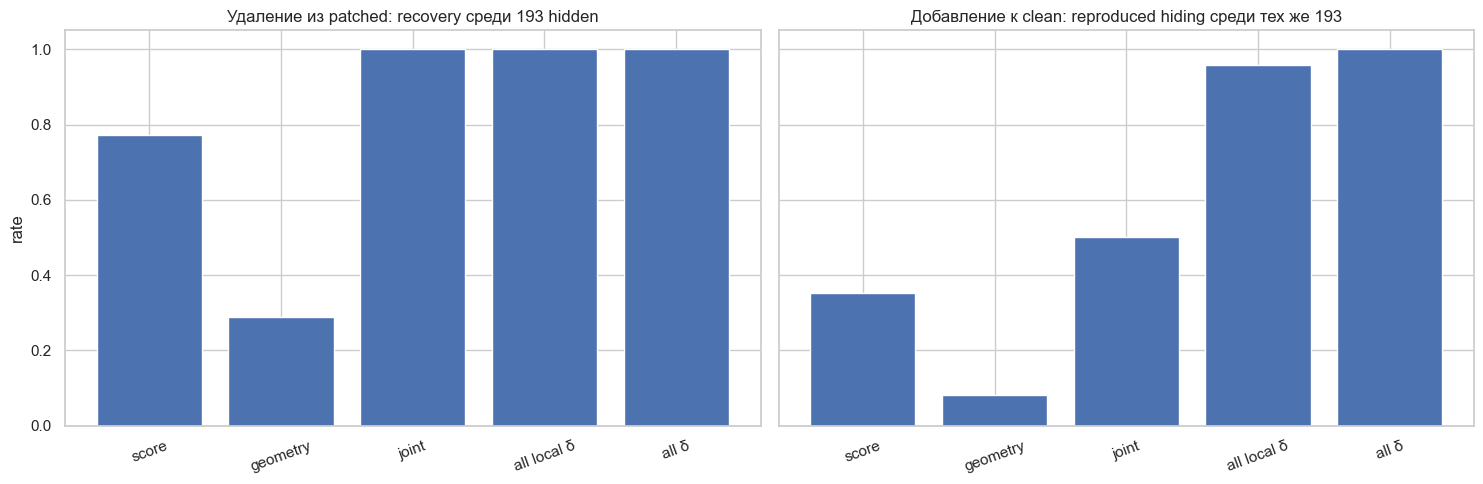

,интервенция,успехов,из,rate
0,repair joint,193,193,1.000000
1,transplant joint,97,193,0.502591


In [6]:
summary = full_summary[full_summary.analysis_group.eq("all")].copy()
repair = summary[summary.direction.eq("repair_patched")].set_index("condition")
transplant = summary[summary.direction.eq("transplant_clean")].set_index("condition")
conditions = ["score_rowspace", "geometry_rowspace", "joint_rowspace",
              "full_candidate_windows", "full_maps"]
labels = ["score", "geometry", "joint", "all local δ", "all δ"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
axes[0].bar(labels, [repair.loc[c, "recovery_rate"] for c in conditions])
axes[0].set_title("Удаление из patched: recovery среди 193 hidden")
axes[0].set_ylabel("rate")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(labels, [transplant.loc[c, "reproduced_hiding_rate"] for c in conditions])
axes[1].set_title("Добавление к clean: reproduced hiding среди тех же 193")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "интервенция": ["repair joint", "transplant joint"],
    "успехов": [
        int(round(repair.loc["joint_rowspace", "recovery_rate"] * 193)),
        int(round(transplant.loc["joint_rowspace", "reproduced_hiding_rate"] * 193)),
    ],
    "из": [193, 193],
    "rate": [
        repair.loc["joint_rowspace", "recovery_rate"],
        transplant.loc["joint_rowspace", "reproduced_hiding_rate"],
    ],
}))

На 193 воспроизводимо скрытых объектах:

- удаление joint-компоненты возвращает **193/193 = 100.0%**;
- добавление только joint-компоненты воспроизводит hiding примерно в
  **97/193 = 50.3%**;
- средняя энергия компоненты — **0.287%** полной
  feature-delta.

Следовательно, на этой выборке компонента была необходима всегда, но сама по
себе достаточна примерно в половине случаев. Во второй половине ей требуется
нелинейное взаимодействие с остальной локальной дельтой: перенос всей
локальной дельты воспроизводит 95.9%
hiding.

## 6. Общее пространство между изображениями одного патча

До этого $V$ и $\delta^J$ вычислялись отдельно для каждой пары изображений.
Следующий вопрос: совпадают ли функциональные направления между разными
изображениями?

На 240 train-изображениях строится единый rank-$r$ базис в канонических
координатах `channel × relative_y × relative_x`. Он без дообучения применяется
к 160 holdout-изображениям того же патча. `sensitivity` строится по
нормированным градиентам; `attack` дополнительно взвешивает направления
фактическим эффектом патча.

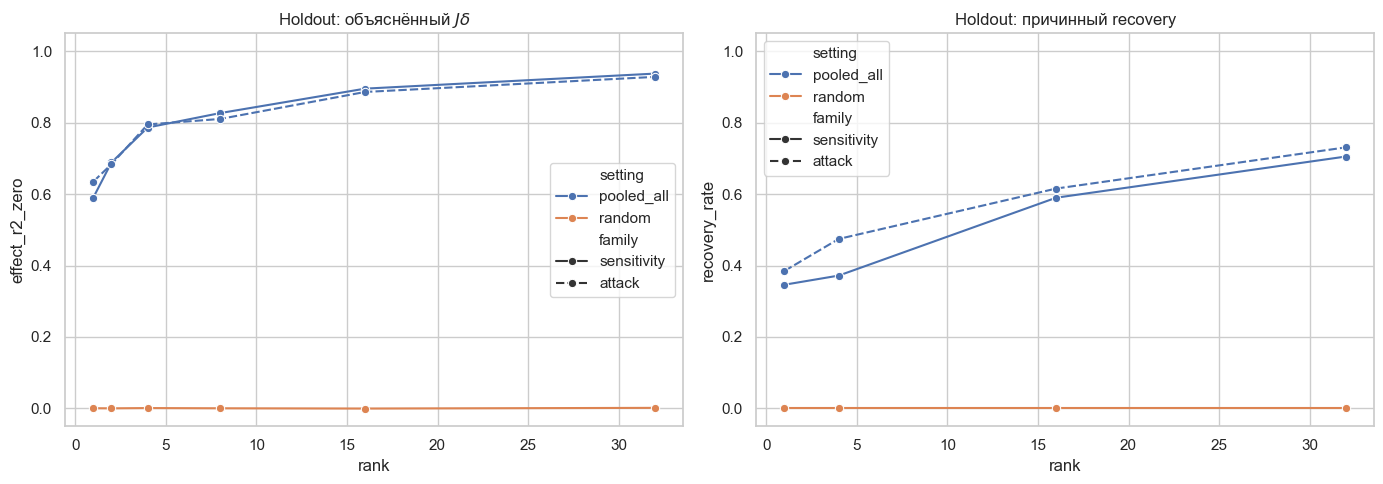

,family,setting,rank,n_examples,n_candidates,mean_gradient_coverage,mean_delta_energy_fraction,effect_r2_zero,effect_cosine
23,sensitivity,pooled_all,32,160,1637,0.8838,0.0126,0.9373,0.9712
59,attack,pooled_all,32,160,1637,0.8733,0.0138,0.9281,0.9643


,family,setting,rank,n_examples,n_hidden_baseline,target_hidden_rate,recovery_rate,clean_endpoint_damage_rate,mean_pre_target_conf
16,sensitivity,pooled_all,32,160,78,0.1438,0.7051,0.0,0.5863
36,attack,pooled_all,32,160,78,0.1312,0.7308,0.0,0.6009


In [7]:
same_a = shared_analytic[
    shared_analytic.setting.isin(["pooled_all", "random"])
]
same_c = shared_causal[
    shared_causal.setting.isin(["pooled_all", "random"])
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=same_a, x="rank", y="effect_r2_zero",
    hue="setting", style="family", marker="o", ax=axes[0],
)
axes[0].set_title("Holdout: объяснённый $Jδ$")
axes[0].set_ylim(-.05, 1.05)
sns.lineplot(
    data=same_c[~same_c.family.eq("none")],
    x="rank", y="recovery_rate",
    hue="setting", style="family", marker="o", ax=axes[1],
)
axes[1].set_title("Holdout: причинный recovery")
axes[1].set_ylim(-.05, 1.05)
plt.tight_layout()
plt.show()

display(shared_analytic[
    shared_analytic.setting.eq("pooled_all") & shared_analytic["rank"].eq(32)
].round(4))
display(shared_causal[
    shared_causal.setting.eq("pooled_all") & shared_causal["rank"].eq(32)
].round(4))

Единый rank-32 базис на holdout объясняет около 93% линейного
score-эффекта при 1.3–1.4% энергии локальной дельты и возвращает 70–73%
скрытых объектов. Случайный базис того же rank возвращает 0%.

Значит, функциональная структура не полностью индивидуальна для изображения.
Однако это ещё могло быть свойством одного конкретного патча.

## 7. Финальный эксперимент: перенос пространства на другой патч

Базис строится только на исходном `data/patch.png` и 240 train-изображениях.
Holdout из 160 изображений атакуется независимо обученным
`general_adv.png`; его активации не участвуют в построении source-базиса.

Оба патча имеют размер $160\times160$ и положение $(0,0)$, модель и выборка
фиксированы. Поэтому это чистый тест **cross-patch**, но пока не cross-model
и не cross-position.

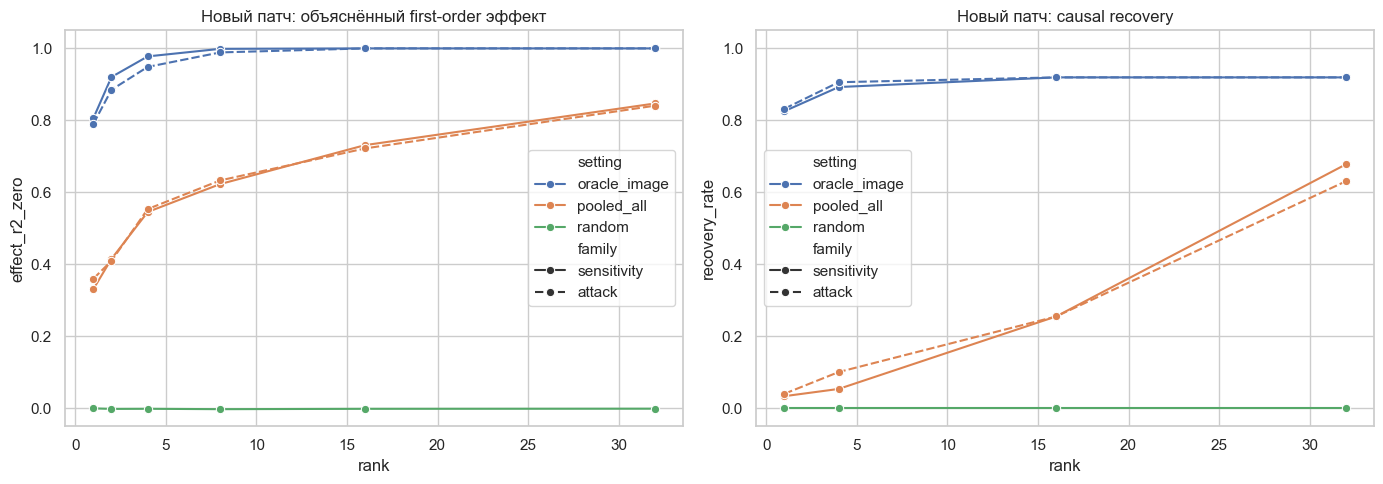

,family,setting,n_hidden_baseline,recovery_rate,mean_pre_target_conf
4,sensitivity,oracle_image,149,0.9195,0.6637
16,sensitivity,pooled_all,149,0.6779,0.4023
24,attack,oracle_image,149,0.9195,0.6637
36,attack,pooled_all,149,0.6309,0.4027
44,sensitivity,random,149,0.0000,0.0490


,family,setting,rank,n_examples,n_candidates,mean_gradient_coverage,mean_delta_energy_fraction,effect_r2_zero,effect_cosine
23,sensitivity,pooled_all,32,160,1637,0.6648,0.0120,0.8470,0.9538
59,attack,pooled_all,32,160,1637,0.6630,0.0129,0.8408,0.9450


In [8]:
cross_c = cross_causal[
    cross_causal.setting.isin(["oracle_image", "pooled_all", "random"])
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=cross_analytic[
        cross_analytic.setting.isin(["oracle_image", "pooled_all", "random"])
    ],
    x="rank", y="effect_r2_zero", hue="setting", style="family",
    marker="o", ax=axes[0],
)
axes[0].set_title("Новый патч: объяснённый first-order эффект")
axes[0].set_ylim(-.05, 1.05)
sns.lineplot(
    data=cross_c[~cross_c.family.eq("none")],
    x="rank", y="recovery_rate", hue="setting", style="family",
    marker="o", ax=axes[1],
)
axes[1].set_title("Новый патч: causal recovery")
axes[1].set_ylim(-.05, 1.05)
plt.tight_layout()
plt.show()

rank32 = cross_causal[
    cross_causal["rank"].eq(32)
    & (
        cross_causal.setting.isin(["oracle_image", "pooled_all", "random"])
    )
][["family", "setting", "n_hidden_baseline", "recovery_rate",
   "mean_pre_target_conf"]]
display(rank32.round(4))
display(cross_analytic[
    cross_analytic.setting.eq("pooled_all") & cross_analytic["rank"].eq(32)
].round(4))

`general_adv` скрывает 149/160 = 93.1% целевых объектов, то есть
существенно сильнее исходного патча. Тем не менее source rank-32 базис:

- `sensitivity`: возвращает 101/149 = **67.8%**;
- `attack`: возвращает 94/149 = **63.1%**;
- случайный базис: **0/149**;
- target-specific image basis: 137/149 = **91.9%**.

Source `sensitivity`-базис покрывает 66.5% якобиана нового патча и объясняет
84.7% его first-order эффекта, используя 1.20% энергии его дельты.

## Итоговый вывод

На исследованной модели разные независимо обученные патчи подавляют детекцию
через **частично общее низкоразмерное score-функциональное пространство**.
Оно в значительной степени является структурой чувствительности модели, а не
уникальной сигнатурой одной картинки или одного патча.

При этом перенос неполный: target-specific базис заметно сильнее, а основной
скачок cross-patch recovery возникает между rank-16 и rank-32. Поэтому
корректная формулировка — «общее функциональное ядро плюс патч-специфические
направления», а не одно универсальное направление.

### Границы результата

- одна архитектура и набор весов;
- два патча;
- одинаковые размер и положение патча;
- фактически исследованный резерв находится на P5;
- вычисление компоненты использует clean–patched пару и остаётся white-box
  механистическим инструментом, а не готовой black-box защитой.